In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [52]:
df = pd.read_csv("29-country_data.csv")

In [53]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [55]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


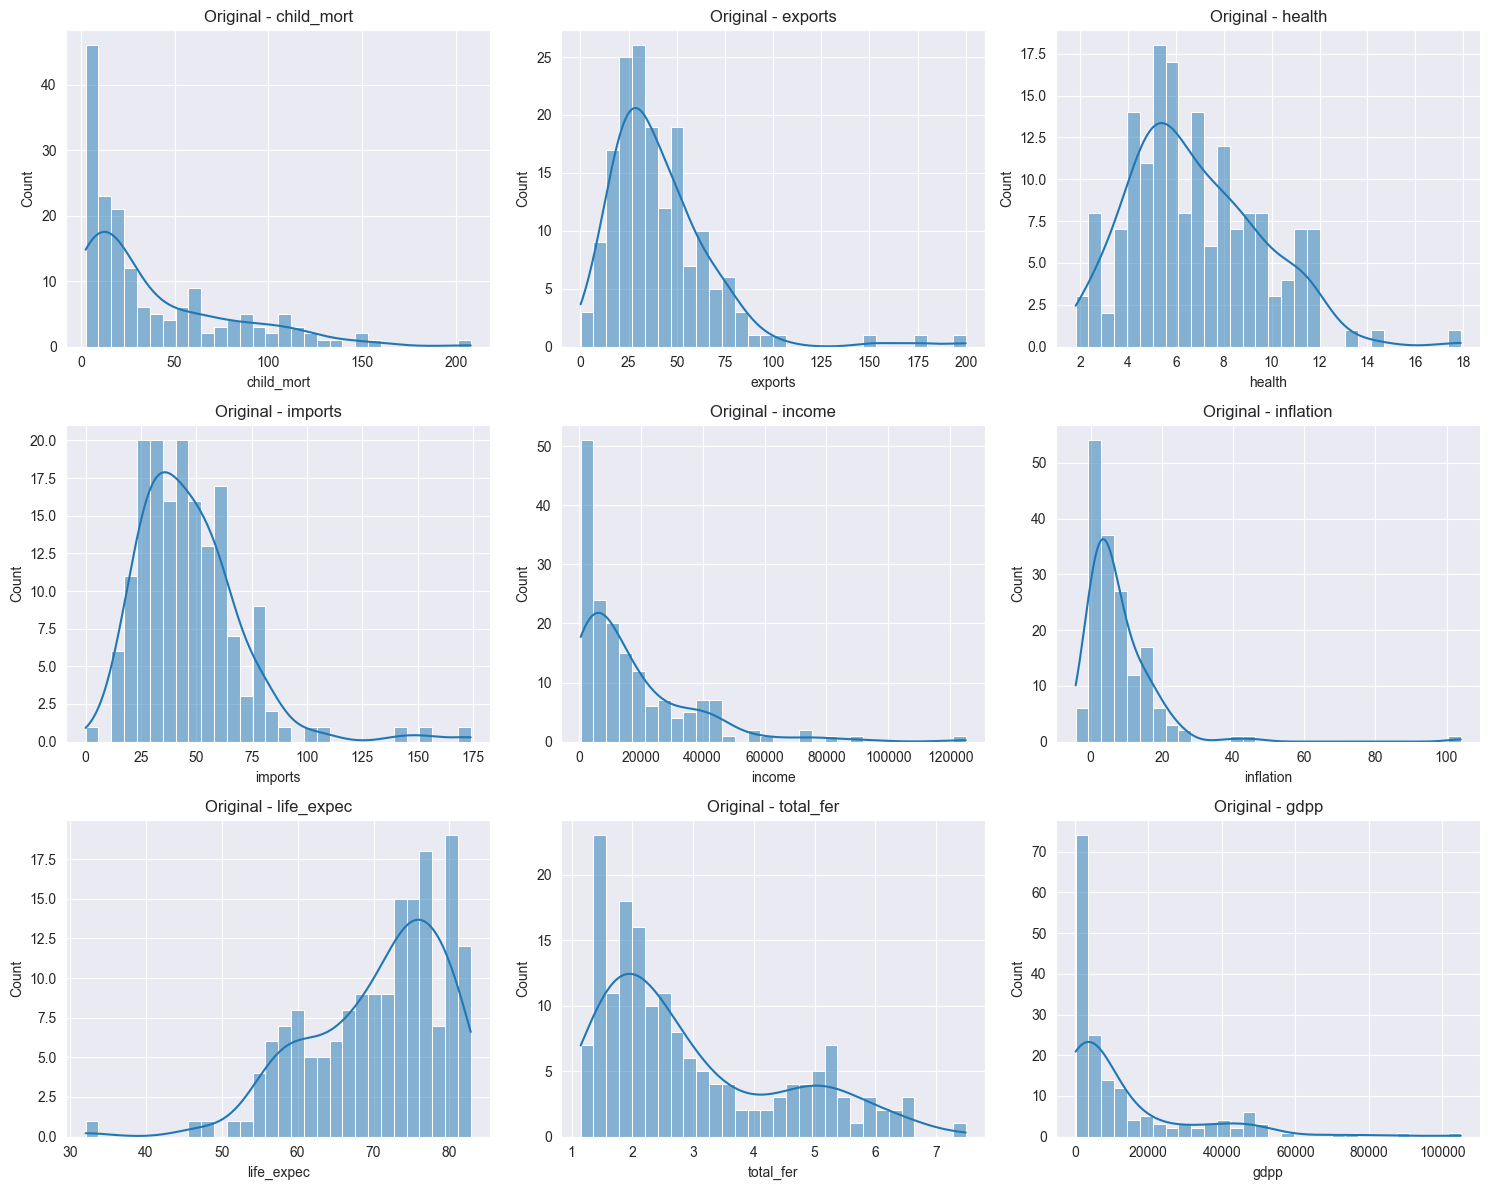

In [56]:
import math

def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for x, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, x)
        sns.histplot(df[col], bins=30,kde=True)
        plt.title(f"{title_prefix}{col}" )

    plt.tight_layout()
    plt.show()

plot_all_histograms(df,title_prefix="Original - ")

<Axes: >

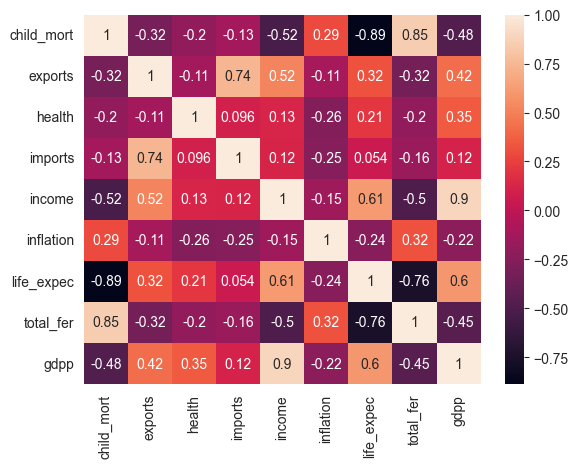

In [57]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [58]:
df2 = df.drop("country",axis=1)

In [59]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [60]:
from sklearn.preprocessing import MinMaxScaler

In [61]:
scaler = MinMaxScaler()
df2 = scaler.fit_transform(df2)

In [62]:
df2 = pd.DataFrame(df2,columns=['child_mort', 'exports', 'health', 'imports', 'income','inflation', 'life_expec', 'total_fer', 'gdpp'])

In [63]:
df2

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242
...,...,...,...,...,...,...,...,...,...
162,0.129503,0.232582,0.213797,0.302609,0.018820,0.063118,0.609467,0.370662,0.026143
163,0.070594,0.142032,0.192666,0.100809,0.127750,0.463081,0.854043,0.208202,0.126650
164,0.100779,0.359651,0.312617,0.460715,0.031200,0.150725,0.808679,0.126183,0.010299
165,0.261441,0.149536,0.209447,0.197397,0.031120,0.257000,0.698225,0.555205,0.010299


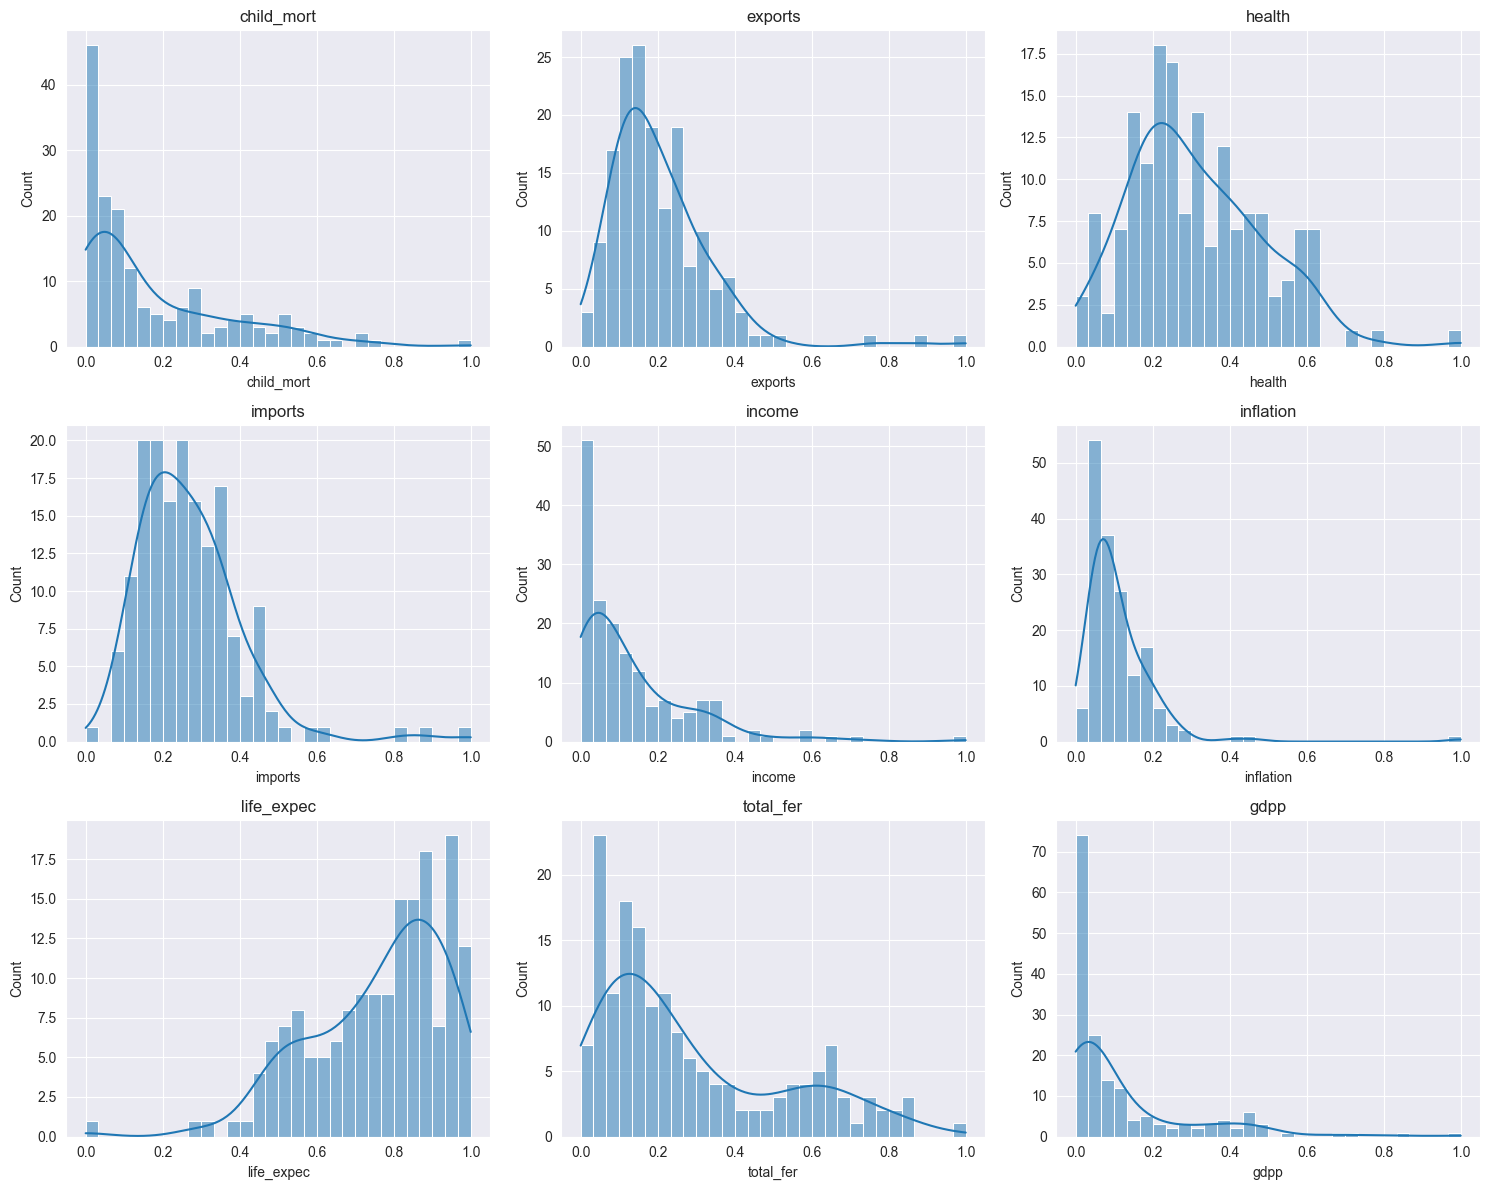

In [64]:
plot_all_histograms(df2)

In [65]:
from sklearn.decomposition import PCA
pca = PCA()

In [66]:
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

In [67]:
pca_df2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [68]:
pca.explained_variance_ratio_

array([0.55001227, 0.13384784, 0.12301053, 0.09749047, 0.03777964,
       0.03013659, 0.01190434, 0.00887791, 0.00694042])

Text(0.5, 1.0, 'variance covered')

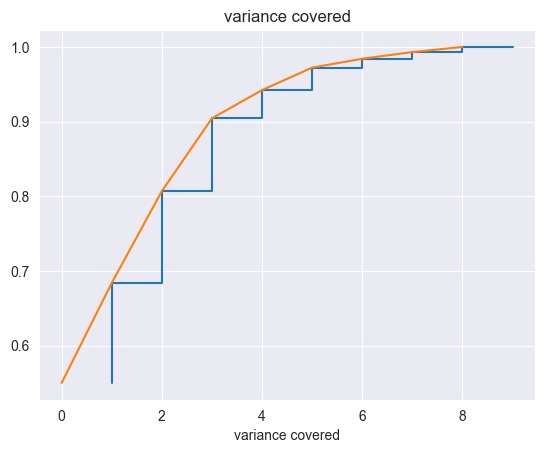

In [69]:
plt.step(list(range(1,10)),np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('variance covered')
plt.title("variance covered")

In [70]:
pca_df2 = pca_df2.drop(columns=[3,4,5,6,7,8])

In [71]:
pca_df2

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


In [72]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [73]:
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit(pca_df2)
    wcss.append(km.inertia_)

In [74]:
wcss

[34.53302925308178,
 17.695395368904084,
 11.270622261541495,
 9.026025307351235,
 7.229093791987213,
 6.571531098687507,
 5.212258602641186,
 4.9515006157581105,
 4.809805953025148,
 4.081392662356766]

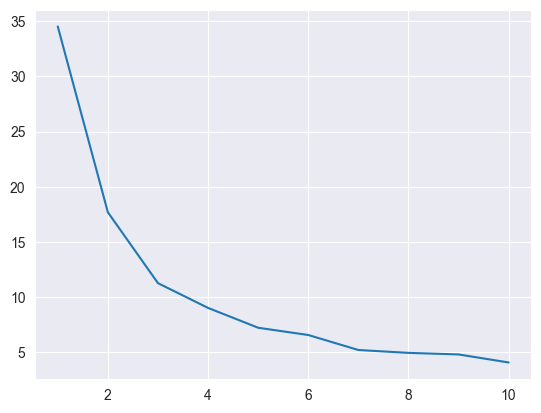

In [75]:
plt.plot(range(1,11),wcss)

In [76]:
model = KMeans(n_clusters=3)
model.fit(pca_df2)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [77]:
labels = model.labels_

In [78]:
silhouette_score(pca_df2,labels)

0.4386320345236685

In [79]:
df["Class"] = labels

In [80]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,0
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,2


Text(0.5, 1.0, 'Income vs class')

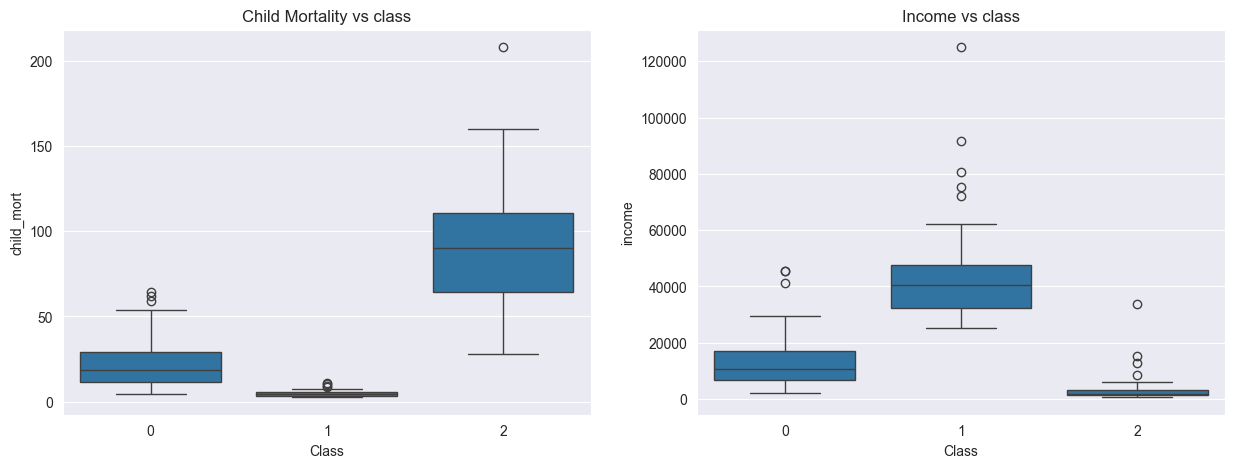

In [81]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=df,x="Class",y="child_mort")
plt.title("Child Mortality vs class")

plt.subplot(1,2,2)
sns.boxplot(data=df,x="Class",y="income")
plt.title("Income vs class")

In [83]:
# 0 => Between 1 and 2
# 1 => no need help
# 2 =>  need help

In [84]:
import plotly.express as px

In [85]:
pca_df2.insert(0,column='Country',value=df["country"])

In [86]:
pca_df2["Class"] = labels

In [87]:
pca_df2

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,2
1,Albania,-0.158474,-0.212092,-0.064189,0
2,Algeria,-0.003686,-0.135867,-0.134182,0
3,Angola,0.650235,0.275975,-0.142672,2
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,0
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,0
163,Venezuela,-0.061133,-0.171339,-0.058586,0
164,Vietnam,-0.115512,-0.032034,-0.195243,0
165,Yemen,0.332968,-0.019824,-0.029989,2


In [88]:
pca_df2.loc[pca_df2["Class"] ==0,"Class"] = "In Between"
pca_df2.loc[pca_df2["Class"] ==1,"Class"] = "No Need Help"
pca_df2.loc[pca_df2["Class"] ==2,"Class"] = "Need Help"

C:\Users\cemal\AppData\Local\Temp\ipykernel_8320\1933213243.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'In Between' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



In [89]:
pca_df2

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Need Help
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,Need Help
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,In Between
163,Venezuela,-0.061133,-0.171339,-0.058586,In Between
164,Vietnam,-0.115512,-0.032034,-0.195243,In Between
165,Yemen,0.332968,-0.019824,-0.029989,Need Help


In [91]:
fig = px.choropleth(
    pca_df2[["Country","Class"]],
    locationmode="country names",
    locations="Country",
    title="Needed Help by Country",
    color = pca_df2["Class"],
    color_discrete_map={
        "Need Help":"Red",
        "No Need Help":"Green",
        "In Between":"Blue",
    }
)

fig.update_geos(fitbounds="locations", visible=True)
fig.show()

C:\Users\cemal\AppData\Local\Temp\ipykernel_8320\2632566895.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [93]:
import plotly.express as px
import pycountry

# Ülke ismini alıp ISO-3 koduna çeviren fonksiyon
def get_iso_alpha3(country_name):
    try:
        # İsme göre ülkeyi bul ve alpha_3 kodunu döndür
        return pycountry.countries.get(name=country_name).alpha_3
    except:
        # Tam eşleşme bulamazsa fuzzy search (yaklaşık arama) dener
        try:
            return pycountry.countries.search_fuzzy(country_name)[0].alpha_3
        except:
            return None # Hiçbir şey bulamazsa None döner

# Mevcut veri setine 'iso_alpha' adında yeni bir sütun ekleyelim
# Not: pca_df2'nin kopyası üzerinde çalışmak güvenlidir
pca_df2['iso_alpha'] = pca_df2['Country'].apply(get_iso_alpha3)

# Haritayı oluştur (locationmode ve locations kısmına dikkat)
fig = px.choropleth(
    pca_df2,
    locationmode="ISO-3",          # BURASI DEĞİŞTİ: Artık ISO-3 kullanıyoruz
    locations="iso_alpha",         # BURASI DEĞİŞTİ: İsim yerine kod sütununu veriyoruz
    title="Needed Help by Country",
    hover_name="Country",          # Üzerine gelince hala ülke ismini göstersin
    color="Class",
    color_discrete_map={
        "Need Help": "Red",
        "No Need Help": "Green",
        "In Between": "Blue",
    }
)

fig.update_geos(fitbounds="locations", visible=True)
fig.show()

In [94]:
#without PCA

In [95]:
df2

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242
...,...,...,...,...,...,...,...,...,...
162,0.129503,0.232582,0.213797,0.302609,0.018820,0.063118,0.609467,0.370662,0.026143
163,0.070594,0.142032,0.192666,0.100809,0.127750,0.463081,0.854043,0.208202,0.126650
164,0.100779,0.359651,0.312617,0.460715,0.031200,0.150725,0.808679,0.126183,0.010299
165,0.261441,0.149536,0.209447,0.197397,0.031120,0.257000,0.698225,0.555205,0.010299


In [107]:
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit(df2)
    wcss.append(km.inertia_)

In [102]:
df2.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [108]:
wcss

[42.798718775687526,
 25.958149703000355,
 19.35198252576052,
 16.781002591696126,
 15.147902267040472,
 13.649864830059702,
 12.645030603139837,
 13.191200694253276,
 10.98754252713873,
 10.282388986604545]

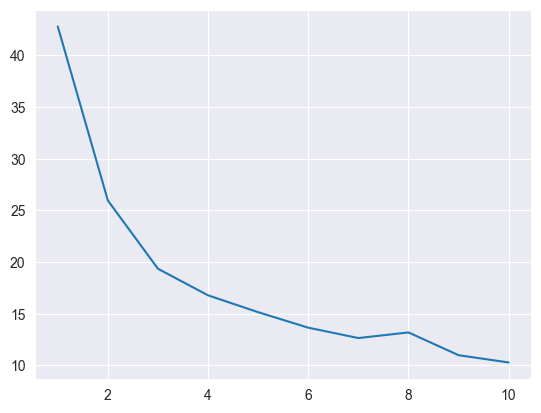

In [109]:
plt.plot(range(1,11),wcss)

In [110]:
model = KMeans(n_clusters=3)
model.fit(df2)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [111]:
labels = model.labels_

In [112]:
silhouette_score(df2,labels)

0.33976487765323604

In [118]:
df["Class"] = labels

In [119]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


Text(0.5, 1.0, 'Income vs class')

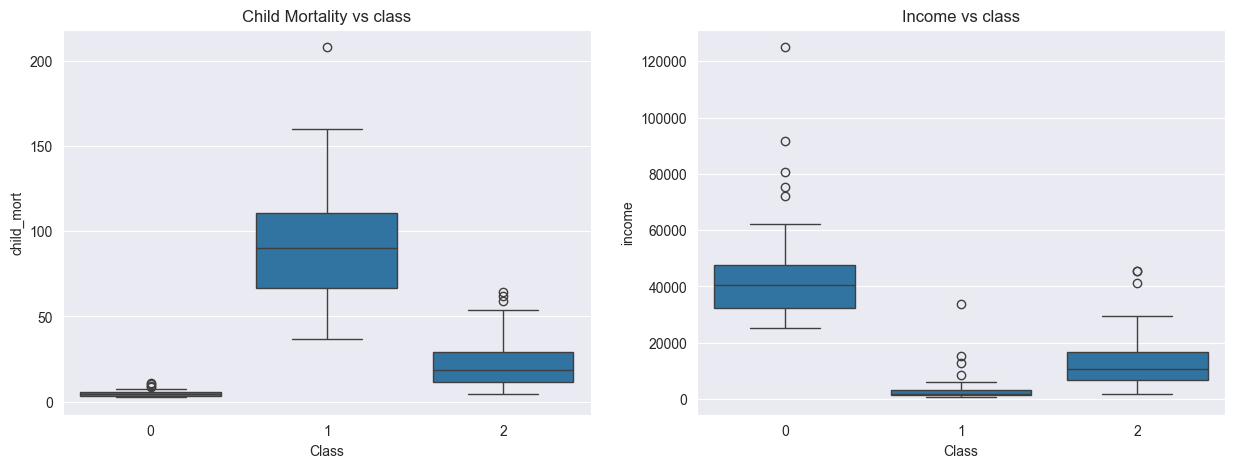

In [120]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=df,x="Class",y="child_mort")
plt.title("Child Mortality vs class")

plt.subplot(1,2,2)
sns.boxplot(data=df,x="Class",y="income")
plt.title("Income vs class")

In [125]:
df4 = df

In [126]:
df4

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


In [127]:
df4["Class"] = df4["Class"].astype("object")

df4.loc[df["Class"] == 0, "Class"] = "No Need Help"
df4.loc[df["Class"] == 1, "Class"] = "Need Help"
df4.loc[df["Class"] == 2, "Class"] = "In Between"

In [130]:
import plotly.express as px
import pycountry

# Ülke ismini alıp ISO-3 koduna çeviren fonksiyon
def get_iso_alpha3(country_name):
    try:
        # İsme göre ülkeyi bul ve alpha_3 kodunu döndür
        return pycountry.countries.get(name=country_name).alpha_3
    except:
        # Tam eşleşme bulamazsa fuzzy search (yaklaşık arama) dener
        try:
            return pycountry.countries.search_fuzzy(country_name)[0].alpha_3
        except:
            return None # Hiçbir şey bulamazsa None döner

# Mevcut veri setine 'iso_alpha' adında yeni bir sütun ekleyelim
# Not: pca_df2'nin kopyası üzerinde çalışmak güvenlidir
df4['iso_alpha'] = df4['country'].apply(get_iso_alpha3)

# Haritayı oluştur (locationmode ve locations kısmına dikkat)
fig = px.choropleth(
    df4,
    locationmode="ISO-3",          # BURASI DEĞİŞTİ: Artık ISO-3 kullanıyoruz
    locations="iso_alpha",         # BURASI DEĞİŞTİ: İsim yerine kod sütununu veriyoruz
    title="Needed Help by Country",
    hover_name="country",          # Üzerine gelince hala ülke ismini göstersin
    color="Class",
    color_discrete_map={
        "Need Help": "Red",
        "No Need Help": "Green",
        "In Between": "Blue",
    }
)

fig.update_geos(fitbounds="locations", visible=True)
fig.show()

In [131]:
# hierarchical

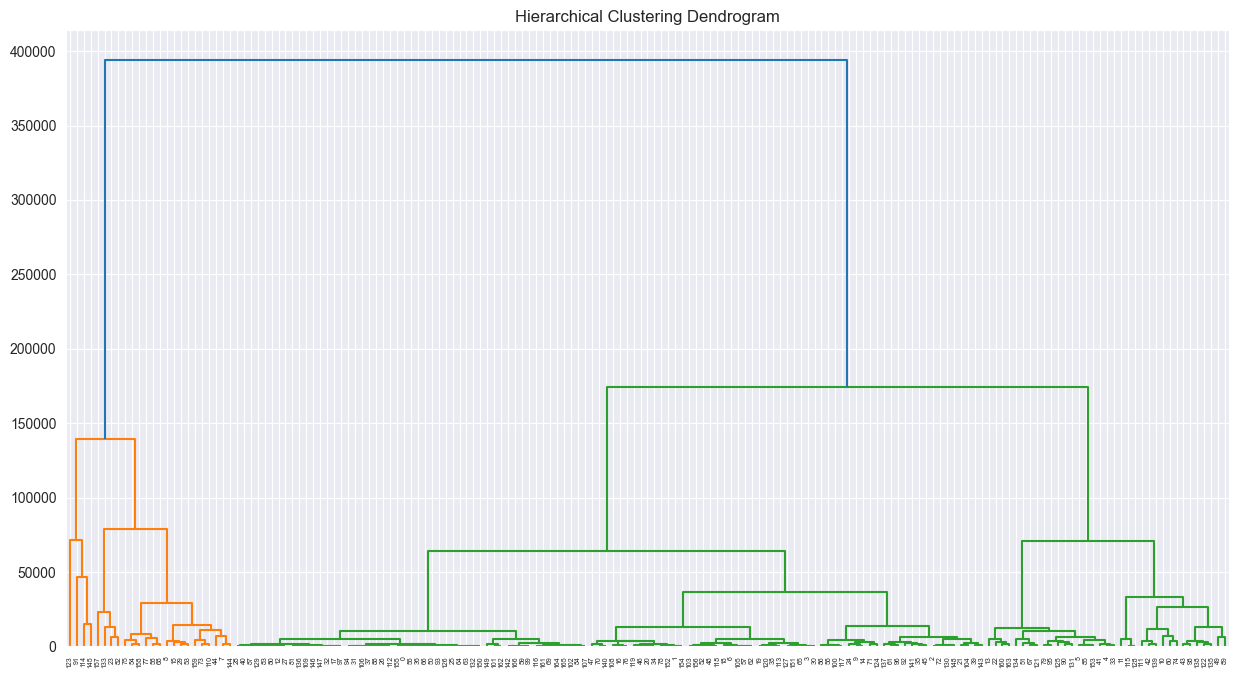

In [138]:
import scipy.cluster.hierarchy as sch

df5 = df4.drop(columns=["country","Class","iso_alpha"])

plt.figure(1, figsize=(15, 8))
dendogram = sch.dendrogram(sch.linkage(df5,method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [139]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=4)
y_hc = hc.fit_predict(df5)
df5["cluster"] = pd.DataFrame(y_hc)

In [140]:
df5.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,3


Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

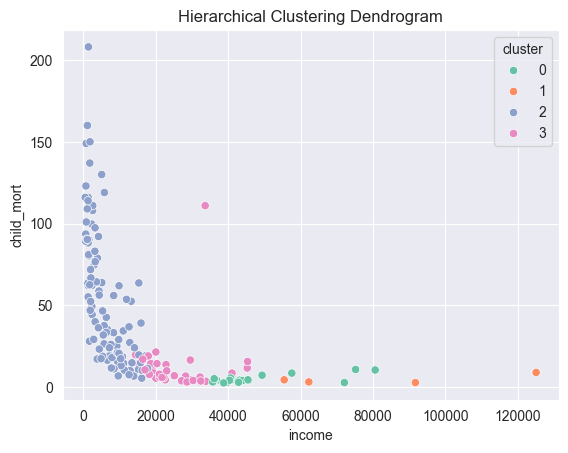

In [141]:
sns.scatterplot(data=df5, x="income", y="child_mort", hue="cluster", palette="Set2")
plt.title("Hierarchical Clustering Dendrogram")

In [142]:
from sklearn.metrics import silhouette_score
print(silhouette_score(df5, y_hc))

0.6085546626256414


In [144]:
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score

features_2D =["income", "child_mort"]
features_3D = ["income", "child_mort","health"]
features_4D = ["income", "child_mort","health","life_expec"]

for feats in [features_2D, features_3D, features_4D]:
    X = df5[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=5)
    y_hc = hc.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)

    print(f"\n features: {feats}")
    print(f"\n silhouette_score: {sil}")
    print(f"\n davies_bouldin_score: {db}")
    print(f"\n calinski_harabasz_score: {ch}")
    print("--------------------------")


 features: ['income', 'child_mort']

 silhouette_score: 0.49293502233833

 davies_bouldin_score: 0.5525660157707393

 calinski_harabasz_score: 273.8009979697658
--------------------------

 features: ['income', 'child_mort', 'health']

 silhouette_score: 0.4045927180948968

 davies_bouldin_score: 0.8436319952992584

 calinski_harabasz_score: 96.91433635598403
--------------------------

 features: ['income', 'child_mort', 'health', 'life_expec']

 silhouette_score: 0.34023132994960464

 davies_bouldin_score: 1.0611925650021137

 calinski_harabasz_score: 97.9968201626284
--------------------------


In [147]:
from sklearn.cluster import HDBSCAN
hdbscan = HDBSCAN()
hdbscan.fit(X_scaled)

,min_cluster_size,5
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [152]:
X_scaled = scaler.fit_transform(df2)

In [156]:
X_scaled = pd.DataFrame(X_scaled, columns=['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'Class'],
      dtype='object')

In [157]:
hdbscan.labels_

array([ 1,  2,  2,  1,  2,  2,  2,  0,  0,  2,  2,  2,  2,  2,  2,  0,  2,
        1,  2,  2,  2,  2,  2,  0,  2,  1,  1,  2,  1,  0,  2,  1,  1,  2,
        2,  2,  1,  1,  1,  2,  1,  2,  0,  0,  0,  2,  2,  2,  2,  1,  1,
        2,  2,  0,  0,  1,  1,  2,  0,  1,  0,  2,  2,  1,  1,  2, -1,  2,
        0,  2,  2,  2,  1,  0,  0,  0,  2,  0,  2,  2,  1,  1,  0,  2,  1,
        2,  2,  1,  1,  2,  2, -1,  2,  1,  1,  2,  2,  1,  0,  1,  2,  2,
        2,  2,  2,  2,  1,  2,  1,  2,  0,  0,  1, -1,  0,  2,  1,  2,  2,
        2,  2,  2,  0, -1,  2,  2,  1,  2,  2,  1,  2,  2,  1, -1,  0,  0,
        2,  2,  0,  0,  2,  2,  1,  2,  0,  0,  2,  1,  2,  1,  1,  2,  2,
        2,  2,  1,  2,  0,  0,  0,  2,  2,  2,  2,  2,  1,  1])

<Axes: xlabel='income', ylabel='child_mort'>

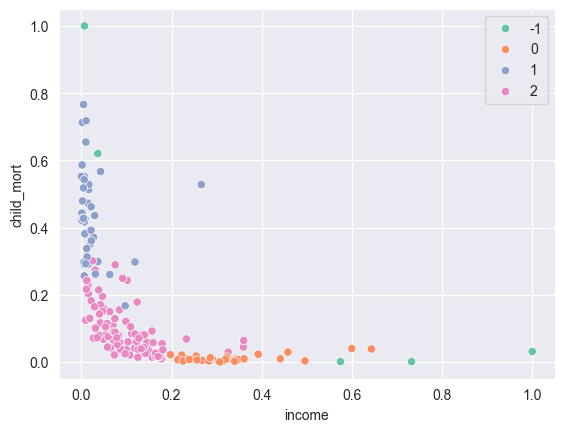

In [159]:
sns.scatterplot(data=X_scaled, x="income", y="child_mort", hue=hdbscan.labels_,palette="Set2")

In [167]:
min_cluster_sizes = [3, 5, 7, 10]
min_samples = [None, 3, 5, 7]

In [168]:
results = []

for min_cluster in min_cluster_sizes:
    for min_sample in min_samples:
        hdb = HDBSCAN(min_cluster_size=min_cluster, min_samples=min_sample).fit(X_scaled)
        labels = hdb.labels_
        # Skip if all points are noise or only one cluster found
        if len(set(labels)) <= 1:
            continue

        silhouette = silhouette_score(X_scaled, labels)

        results.append({
            'min_cluster_size': min_cluster,
            'min_samples': min_sample,
            'Silhouette': silhouette,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        })

# Convert to DataFrame and sort by silhouette
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Silhouette', ascending=False)

In [169]:
results_df

,min_cluster_size,min_samples,Silhouette,n_clusters
5,5,3.0,0.541104,3
9,7,3.0,0.541104,3
13,10,3.0,0.541104,3
2,3,5.0,0.540194,3
10,7,5.0,0.540194,3
14,10,5.0,0.540194,3
4,5,NaN,0.540194,3
6,5,5.0,0.540194,3
11,7,7.0,0.537024,3
8,7,NaN,0.537024,3
